In [41]:
import os
import random
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

# 2) Dataset Overview

In [42]:
DATASET_DIR = r"C:\Users\shbka\OneDrive\Desktop\Lumbar Disc Herniation Detection\Data-0"
normal_folder = r"C:\Users\shbka\OneDrive\Desktop\Lumbar Disc Herniation Detection\Data-0\Normal"
abnormal_folder = r"C:\Users\shbka\OneDrive\Desktop\Lumbar Disc Herniation Detection\Data-0\Abnormal"

classes = ['Normal', 'Abnormal']
folders = [normal_folder, abnormal_folder]

data = []
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

for label in classes:
    class_dir = os.path.join(DATASET_DIR, label)
    
    if not os.path.exists(class_dir):
        print(f"Warning: Folder not found -> {class_dir}")
        continue
    
    for file_name in os.listdir(class_dir):
        if file_name.lower().endswith(valid_extensions):
            img_path = os.path.join(class_dir, file_name)
            data.append({
                "image_path": img_path,
                "label": label
            })

df = pd.DataFrame(data)

print("Dataset Overview")
print("=" * 40)
print(f"Total images: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print("\nClass distribution:")
print(df["label"].value_counts())

Dataset Overview
Total images: 1426
Number of classes: 2

Class distribution:
label
Abnormal    755
Normal      671
Name: count, dtype: int64


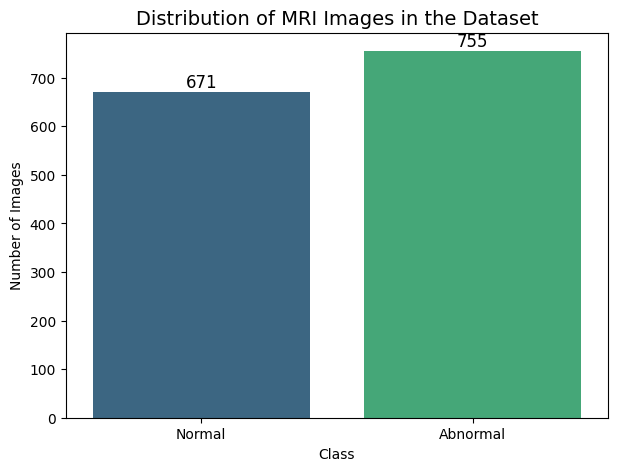

In [43]:
counts = [671, 755]

plt.figure(figsize=(7, 5))
sns.barplot(
    x=classes,
    y=counts,
    palette="viridis"
)
plt.title("Distribution of MRI Images in the Dataset", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center', fontsize=12)

plt.grid(axis='y', linestyle='', alpha=0.6)
plt.show()

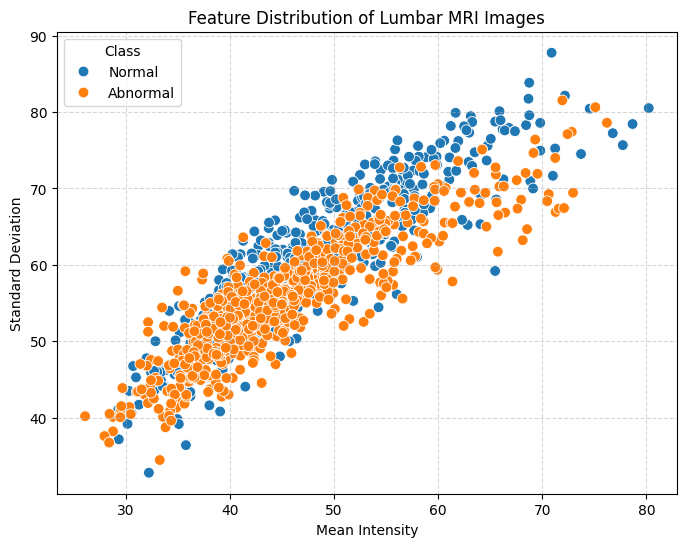

In [44]:
data = []

def extract_features(folder, label_name):
    for f in os.listdir(folder):
        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        mean_intensity = np.mean(img)
        std_intensity = np.std(img)

        data.append([mean_intensity, std_intensity, label_name])

extract_features(normal_folder, "Normal")
extract_features(abnormal_folder, "Abnormal")

means = [x[0] for x in data]
stds = [x[1] for x in data]
labels = [x[2] for x in data]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=means, y=stds, hue=labels, s=60)
plt.title("Feature Distribution of Lumbar MRI Images")
plt.xlabel("Mean Intensity")
plt.ylabel("Standard Deviation")
plt.legend(title="Class")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

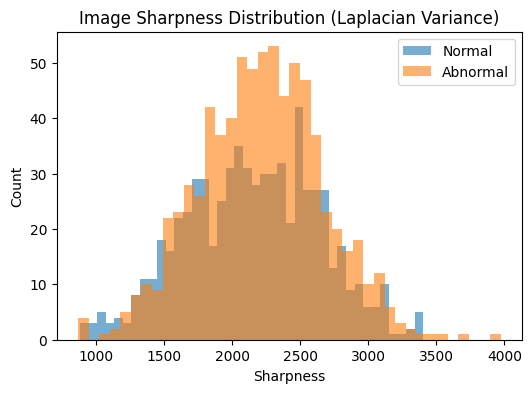

Normal: mean=2152.93, std=491.30
Abnormal: mean=2211.54, std=456.44


In [45]:
def laplacian_variance(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(img, cv2.CV_64F).var()

sharpness = {}

for cls in classes:
    values = []
    cls_path = os.path.join(DATASET_DIR, cls)

    for img in os.listdir(cls_path):
        v = laplacian_variance(os.path.join(cls_path, img))
        values.append(v)

    sharpness[cls] = np.array(values)

plt.figure(figsize=(6, 4))

for cls in classes:
    plt.hist(sharpness[cls], bins=40, alpha=0.6, label=cls)

plt.title("Image Sharpness Distribution (Laplacian Variance)")
plt.xlabel("Sharpness")
plt.ylabel("Count")
plt.legend()
plt.show()

for cls in classes:
    print(f"{cls}: mean={sharpness[cls].mean():.2f}, std={sharpness[cls].std():.2f}")

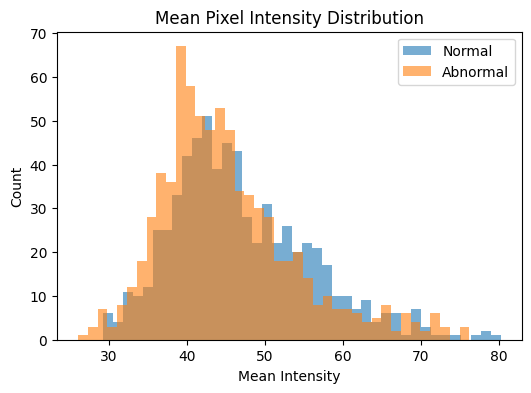

Normal: mean=47.02, std=8.95
Abnormal: mean=45.18, std=8.79


In [46]:
intensity_stats = {}

for cls in classes:
    values = []
    cls_path = os.path.join(DATASET_DIR, cls)

    for img in os.listdir(cls_path):
        im = Image.open(os.path.join(cls_path, img)).convert("L")
        values.append(np.array(im).mean())

    intensity_stats[cls] = np.array(values)

plt.figure(figsize=(6, 4))

for cls in classes:
    plt.hist(intensity_stats[cls], bins=40, alpha=0.6, label=cls)

plt.title("Mean Pixel Intensity Distribution")
plt.xlabel("Mean Intensity")
plt.ylabel("Count")
plt.legend()
plt.show()

for cls in classes:
    print(f"{cls}: mean={intensity_stats[cls].mean():.2f}, std={intensity_stats[cls].std():.2f}")

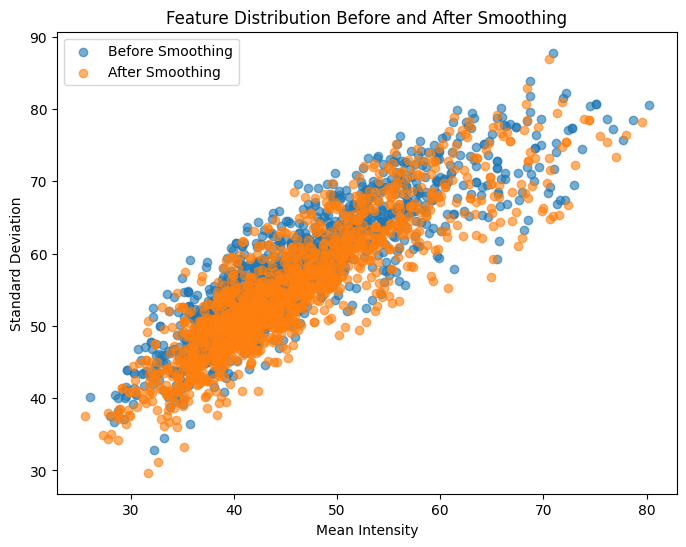

In [47]:
mean_before = []
std_before = []
mean_after = []
std_after = []


for folder in folders:
    for f in os.listdir(folder):

        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        mean_before.append(np.mean(img))
        std_before.append(np.std(img))

        smooth = cv2.bilateralFilter(img, 5, 50, 50)

        mean_after.append(np.mean(smooth))
        std_after.append(np.std(smooth))

plt.figure(figsize=(8, 6))
plt.scatter(mean_before, std_before, alpha=0.6, label="Before Smoothing")
plt.scatter(mean_after, std_after, alpha=0.6, label="After Smoothing")
plt.title("Feature Distribution Before and After Smoothing")
plt.xlabel("Mean Intensity")
plt.ylabel("Standard Deviation")
plt.legend()
plt.show()

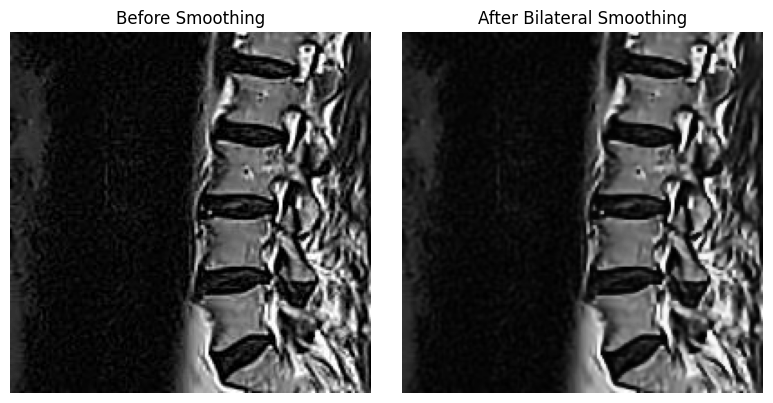

In [48]:
all_images = []

for folder in folders:
    for f in os.listdir(folder):
        path = os.path.join(folder, f)
        if os.path.isfile(path):
            all_images.append(path)

img_path = random.choice(all_images)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (200, 200))

smooth = cv2.bilateralFilter(img, 1, 50, 50)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Before Smoothing")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(smooth, cmap='gray')
plt.title("After Bilateral Smoothing")
plt.axis("off")
plt.tight_layout()
plt.show()

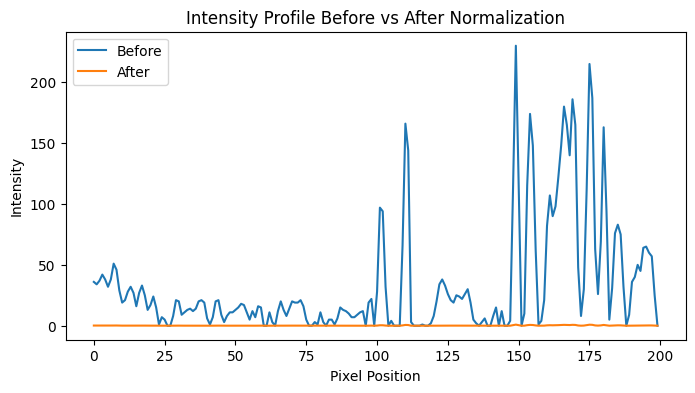

In [49]:
img = img  
norm = img / 255.0
row = 100

plt.figure(figsize=(8, 4))
plt.plot(img[row], label="Before")
plt.plot(norm[row], label="After")
plt.title("Intensity Profile Before vs After Normalization")
plt.xlabel("Pixel Position")
plt.ylabel("Intensity")
plt.legend()
plt.show()

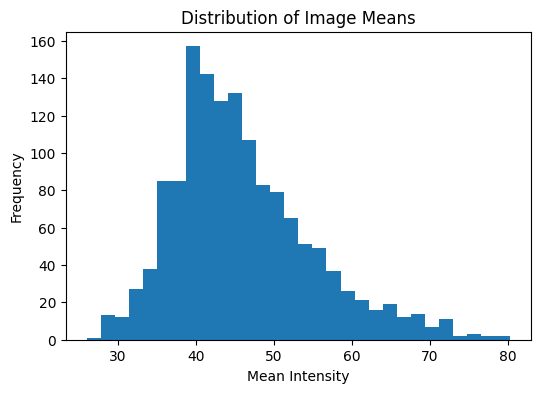

In [50]:
images = []

for folder in folders:
    for f in os.listdir(folder):

        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        images.append(img)


means = [np.mean(img) for img in images]

plt.figure(figsize=(6, 4))
plt.hist(means, bins=30)
plt.title("Distribution of Image Means")
plt.xlabel("Mean Intensity")
plt.ylabel("Frequency")
plt.show()

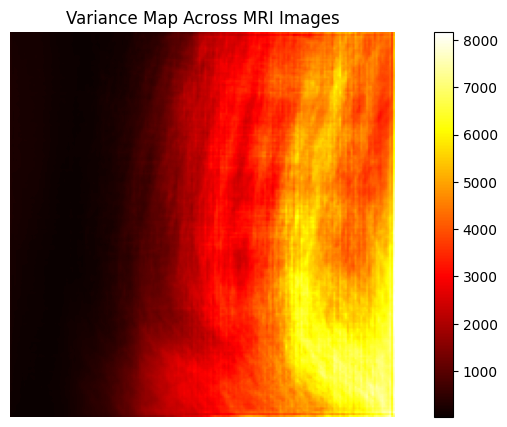

In [51]:
images = []

for folder in folders:
    for f in os.listdir(folder):

        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        images.append(img)

images = np.array(images)
var_img = np.var(images, axis=0)

plt.figure(figsize=(10, 5))
plt.imshow(var_img, cmap='hot')
plt.title("Variance Map Across MRI Images")
plt.axis('off')
plt.colorbar()
plt.show()

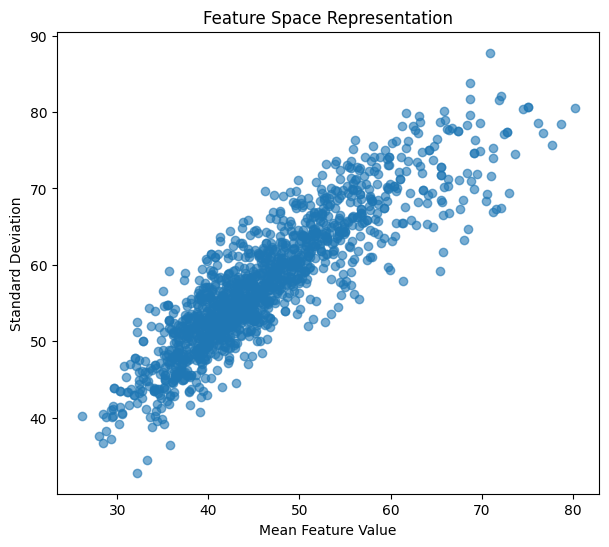

In [52]:
x = [] 

for folder in folders:
    for f in os.listdir(folder):

        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        # Resize
        img = cv2.resize(img, (200, 200))

        # Flatten
        feature_vector = img.flatten()

        x.append(feature_vector)

x = np.array(x)

means = np.mean(x, axis=1)
stds = np.std(x, axis=1)

plt.figure(figsize=(7, 6))
plt.scatter(means, stds, alpha=0.6)
plt.xlabel("Mean Feature Value")
plt.ylabel("Standard Deviation")
plt.title("Feature Space Representation")
plt.show()

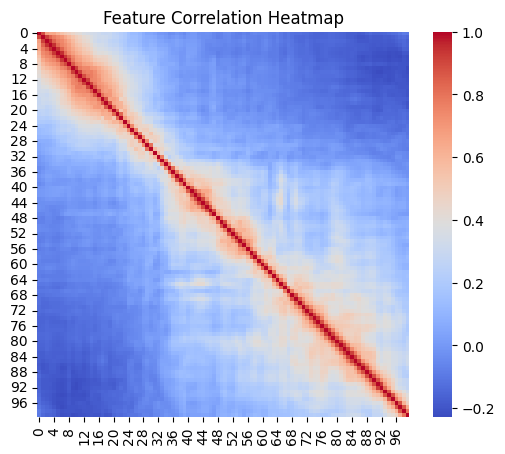

In [53]:
subset = x[:, :100]  

corr = np.corrcoef(subset, rowvar=False)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Total images: 1426
Total labels: 1426


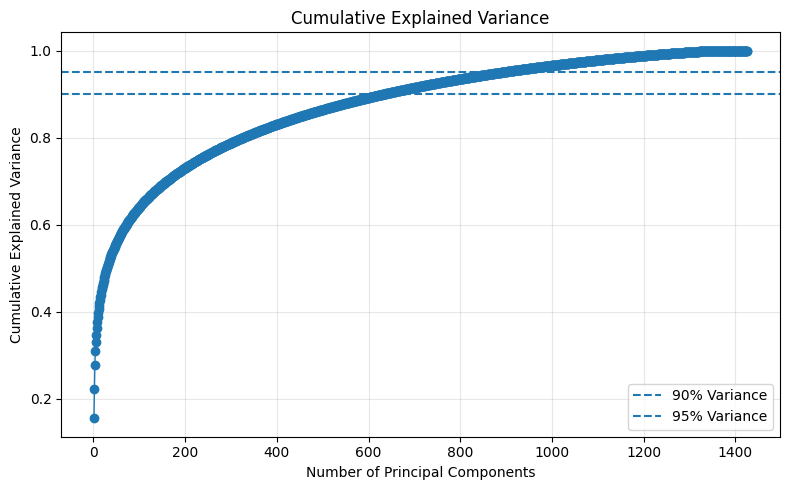

In [54]:
images = []
labels = []
IMG_SIZE = 200

for file_name in os.listdir(normal_folder):
    file_path = os.path.join(normal_folder, file_name)
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(0)

for file_name in os.listdir(abnormal_folder):
    file_path = os.path.join(abnormal_folder, file_name)
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(1)

print("Total images:", len(images))
print("Total labels:", len(labels))

x1 = np.array([img.flatten() for img in images], dtype=np.float32)
y = np.array(labels)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x1)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', linewidth=1)
plt.axhline(y=0.90, linestyle='--', label='90% Variance')
plt.axhline(y=0.95, linestyle='--', label='95% Variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cumulative_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1